# Two-Dimensional Interpolation

Two-dimensional interpolation estimates unknown values on a surface from measurements available at discrete locations. In computational physics, it is widely used to reconstruct scalar fields such as temperature, pressure, concentration, and electric potential from sampled data. This notebook demonstrates two-dimensional interpolation using a synthetic temperature distribution.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interpn
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [13]:
np.random.seed(42)
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Sample Data

The reference temperature field is defined as

$$T(x,y)=1000e^{-x^2}e^{-y}$$

where the temperature decreases exponentially along the $y$-direction while following a Gaussian distribution along the $x$-direction. This analytical function serves as the reference solution for evaluating the interpolation methods.

In [14]:
def T_func(x, y):
    return 1000*np.exp(-x**2) * np.exp(-y)

A structured grid of temperature measurements is generated from the analytical solution, and small random perturbations are added to simulate experimental measurement noise.

In [15]:
x = np.linspace(-2, 2, 25)
y = np.linspace(0, 4, 25)

In [16]:
X, Y = np.meshgrid(x, y, indexing="ij")
T = T_func(X, Y)
T_noisy = T + np.random.normal(0, 1, size=T.shape)

The heat map illustrates the sampled temperature field prior to interpolation.

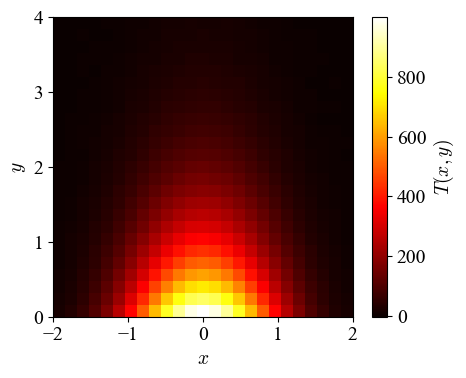

In [17]:
plt.figure(figsize=(5, 4))
plt.imshow(T_noisy.T, extent=[-2,2,0,4], origin="lower", cmap="hot")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.colorbar(label=r"$T(x,y)$")
plt.tight_layout()
plt.show()

## Interpolation Methods

Two-dimensional interpolation constructs a continuous surface that passes through the available sample points. Given measurements

$$(x_i, y_j, T_{ij})$$

the objective is to estimate the temperature at an arbitrary location

$$T(x,y)$$

Linear interpolation approximates the surface using piecewise planar elements defined by neighboring sample points. Higher-order methods employ piecewise polynomial approximations to improve smoothness and accuracy. In this notebook, the interpolated temperature field is evaluated using three interpolation methods:

* Linear interpolation, which provides a piecewise linear approximation.
* Cubic interpolation, which employs piecewise third-degree polynomials to produce a smoother surface.
* Quintic interpolation, which uses piecewise fifth-degree polynomials to further improve smoothness for sufficiently dense and smooth datasets.

The interpolation coefficients are determined automatically from the neighboring grid points. In practice, `scipy.interpolate.interpn` constructs the required multidimensional interpolants and evaluates the interpolated temperature field over a finer grid.

In [18]:
x_fine = np.linspace(-2, 2, 100)
y_fine = np.linspace(0, 4, 100)
Xf, Yf = np.meshgrid(x_fine, y_fine, indexing="ij")
xi = np.stack([Xf, Yf], axis=-1)
points = (x, y)

In [19]:
T_linear = interpn(points, T_noisy, xi, method="linear")
T_cubic = interpn(points, T_noisy, xi, method="cubic")
T_quintic = interpn(points, T_noisy, xi, method="quintic")
T_true = T_func(Xf, Yf)

The interpolated temperature fields are compared with the analytical solution to illustrate the influence of interpolation order on reconstruction accuracy.

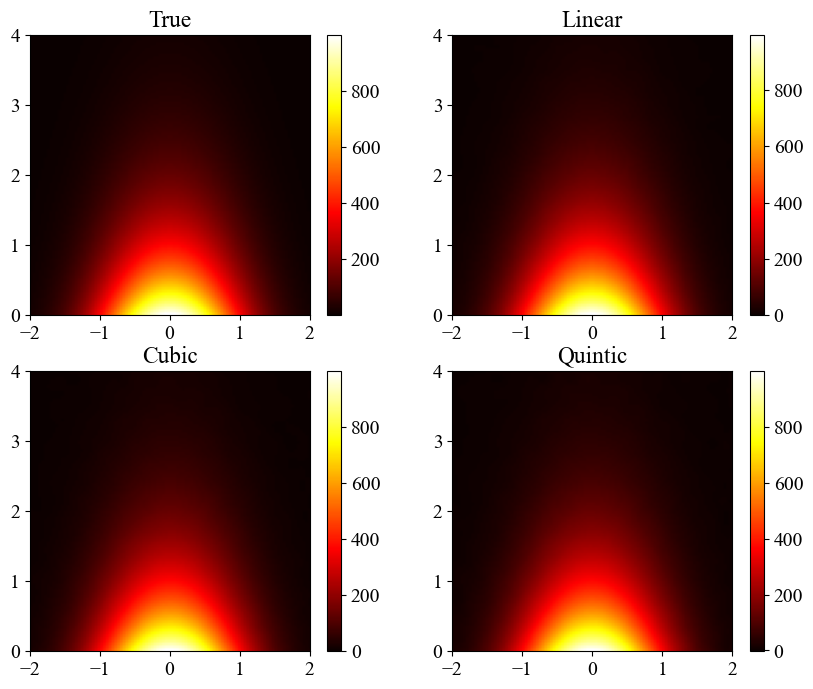

In [20]:
plt.figure(figsize=(10, 8))
plt.tight_layout()

plt.subplot(2,2,1)
plt.title("True")
plt.imshow(T_true.T, extent=[-2,2,0,4], origin="lower", cmap="hot")
plt.colorbar()

plt.subplot(2,2,2)
plt.title("Linear")
plt.imshow(T_linear.T, extent=[-2,2,0,4], origin="lower", cmap="hot")
plt.colorbar()

plt.subplot(2,2,3)
plt.title("Cubic")
plt.imshow(T_cubic.T, extent=[-2,2,0,4], origin="lower", cmap="hot")
plt.colorbar()

plt.subplot(2,2,4)
plt.title("Quintic")
plt.imshow(T_quintic.T, extent=[-2,2,0,4], origin="lower", cmap="hot")
plt.colorbar()

plt.show()

## Model Evaluation

The interpolation accuracy is evaluated using the mean absolute error (MAE),

$$
\mathrm{MAE}=\frac{1}{n}\sum_{i=1}^{n}\left|T_i-\hat{T}_i\right|,
$$

and the root mean squared error (RMSE),

$$
\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(T_i-\hat{T}_i)^2},
$$

where $T_i$ denotes the analytical temperature and $\hat{T}_i$ the interpolated temperature. These metrics quantify the accuracy of each interpolation method.

In [21]:
def eval(name, pred):
    mae = mean_absolute_error(T_true.ravel(), pred.ravel())
    rmse = root_mean_squared_error(T_true.ravel(), pred.ravel())
    print(f"{name}: MAE={mae:.5f}, RMSE={rmse:.5f}")

In [22]:
eval("Linear", T_linear)
eval("Cubic", T_cubic)
eval("Quintic", T_quintic)

Linear: MAE=0.72607, RMSE=0.99215
Cubic: MAE=0.68056, RMSE=0.85942
Quintic: MAE=0.79279, RMSE=1.03404


## Key Insights

* Two-dimensional interpolation reconstructs continuous scalar fields from discrete spatial measurements.
* The interpolation quality depends on both the sampling density and the characteristics of the underlying field.
* MAE and RMSE provide quantitative measures for comparing interpolation accuracy.